# EV Battery Failure Prediction — CatBoost Classification Pipeline

**Author:** Data Scientist  
**Dataset:** EV Battery Failure Prediction Dataset  
**Target Variable:** `battery_failure` (Binary: 0 = Normal, 1 = Failure)  
**Algorithm:** CatBoost Classifier  

---

## Project Overview

Electric vehicle (EV) battery failures pose significant risks to vehicle safety, operational reliability, and total cost of ownership. Early and accurate detection of potential battery failures enables preventive maintenance strategies that mitigate thermal runaway events, reduce downtime, and extend overall battery lifespan.

This notebook presents a complete, production-ready machine learning pipeline for binary classification of EV battery failure using **CatBoost** — a gradient boosting algorithm specifically designed to handle categorical features natively, missing values without imputation, and class imbalance, all of which are key characteristics of this dataset.

### Pipeline Stages

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Model Training with Cross-Validation
7. Hyperparameter Tuning (Optuna)
8. Final Model Training
9. Model Evaluation
10. Feature Importance & SHAP Analysis
11. Inference Pipeline
12. Model Persistence

---
## 1. Import Libraries

In [43]:
import os
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import optuna

from catboost import CatBoostClassifier, Pool, cv as catboost_cv

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTENC

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0"]

BASE_DIR      = Path("../")
DATASET_PATH  = BASE_DIR / "Dataset" / "ev battery_failure prediction Dataset.csv"
MODEL_DIR     = Path("./saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("All libraries imported successfully.")
print(f"Dataset path : {DATASET_PATH.resolve()}")
print(f"Model output : {MODEL_DIR.resolve()}")

All libraries imported successfully.
Dataset path : C:\Users\admin\Documents\Portofolio\EV Battery Health Prediction\Dataset\ev battery_failure prediction Dataset.csv
Model output : C:\Users\admin\Documents\Portofolio\EV Battery Health Prediction\Model\saved_models


---
## 2. Load Dataset

In [44]:
df_raw = pd.read_csv(DATASET_PATH)

print(f"Shape          : {df_raw.shape}")
print(f"Columns        : {df_raw.shape[1]}")
print(f"Rows           : {df_raw.shape[0]:,}")
df_raw.head(3)

Shape          : (20000, 70)
Columns        : 70
Rows           : 20,000


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Ford,Mustang Mach-E,Truck,2022.0,Northvolt,NMC,NaN,AWD,290844.3,...,1.0,NaN,0.0,30.37,73.05,98.14,89.73,47.11,6748.0,0
1,EV100001,Tata,Tiago EV,Truck,2017.0,CATL,NCA,38.71,RWD,182239.5,...,0.0,1.0,0.0,67.94,82.50,NaN,NaN,55.38,5211.0,0
2,EV100002,Volkswagen,ID.3,Crossover,2016.0,BYD Battery,LFP,131.29,FWD,249369.3,...,0.0,1.0,0.0,74.84,90.33,60.02,86.84,74.54,4040.0,0


In [45]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 70 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vehicle_id                       20000 non-null  str    
 1   vehicle_brand                    19356 non-null  str    
 2   vehicle_model                    19180 non-null  str    
 3   vehicle_type                     19356 non-null  str    
 4   manufacturing_year               19018 non-null  float64
 5   battery_manufacturer             19382 non-null  str    
 6   battery_chemistry                19278 non-null  str    
 7   battery_capacity_kwh             19310 non-null  float64
 8   drive_type                       19274 non-null  str    
 9   odometer_km                      19134 non-null  float64
 10  vehicle_age_years                19232 non-null  float64
 11  fleet_or_private                 19106 non-null  str    
 12  battery_serial               

---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Class Distribution

The target variable `battery_failure` is a binary label. Understanding its distribution is critical because class imbalance will directly influence model bias and the choice of evaluation metrics.

Target Distribution:
  Class 0 : 18,616 (93.08%)
  Class 1 : 1,384 (6.92%)

Imbalance Ratio (0:1) = 13.45:1


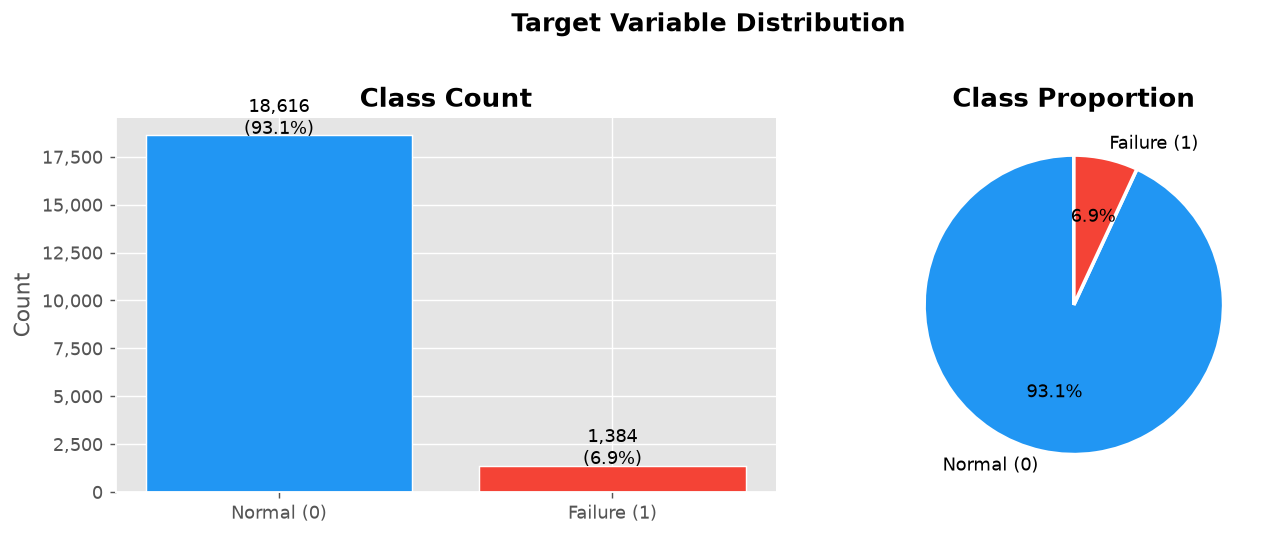

In [46]:
target_counts = df_raw["battery_failure"].value_counts()
target_pct    = df_raw["battery_failure"].value_counts(normalize=True) * 100

print("Target Distribution:")
for label, count in target_counts.items():
    print(f"  Class {label} : {count:,} ({target_pct[label]:.2f}%)")

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nImbalance Ratio (0:1) = {imbalance_ratio:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(
    ["Normal (0)", "Failure (1)"],
    target_counts.values,
    color=PALETTE[:2],
    edgecolor="white",
    linewidth=0.8,
)
for i, (count, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, count + 80, f"{count:,}\n({pct:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Class Count", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].pie(
    target_counts.values,
    labels=["Normal (0)", "Failure (1)"],
    autopct="%1.1f%%",
    colors=PALETTE[:2],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Class Proportion", fontweight="bold")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / "eda_class_distribution.png", bbox_inches="tight")
plt.show()

### 3.2 Missing Value Analysis

In [47]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(f"Columns with missing values: {len(missing_df)}")
missing_df

Columns with missing values: 67


,Missing Count,Missing %
fast_charge_ratio,988,4.94
average_speed,984,4.92
manufacturing_year,982,4.91
home_charging_ratio,980,4.90
sensor_fault_count,968,4.84
...,...,...
pack_voltage,618,3.09
battery_manufacturer,618,3.09
remaining_capacity,614,3.07
average_charging_time,614,3.07


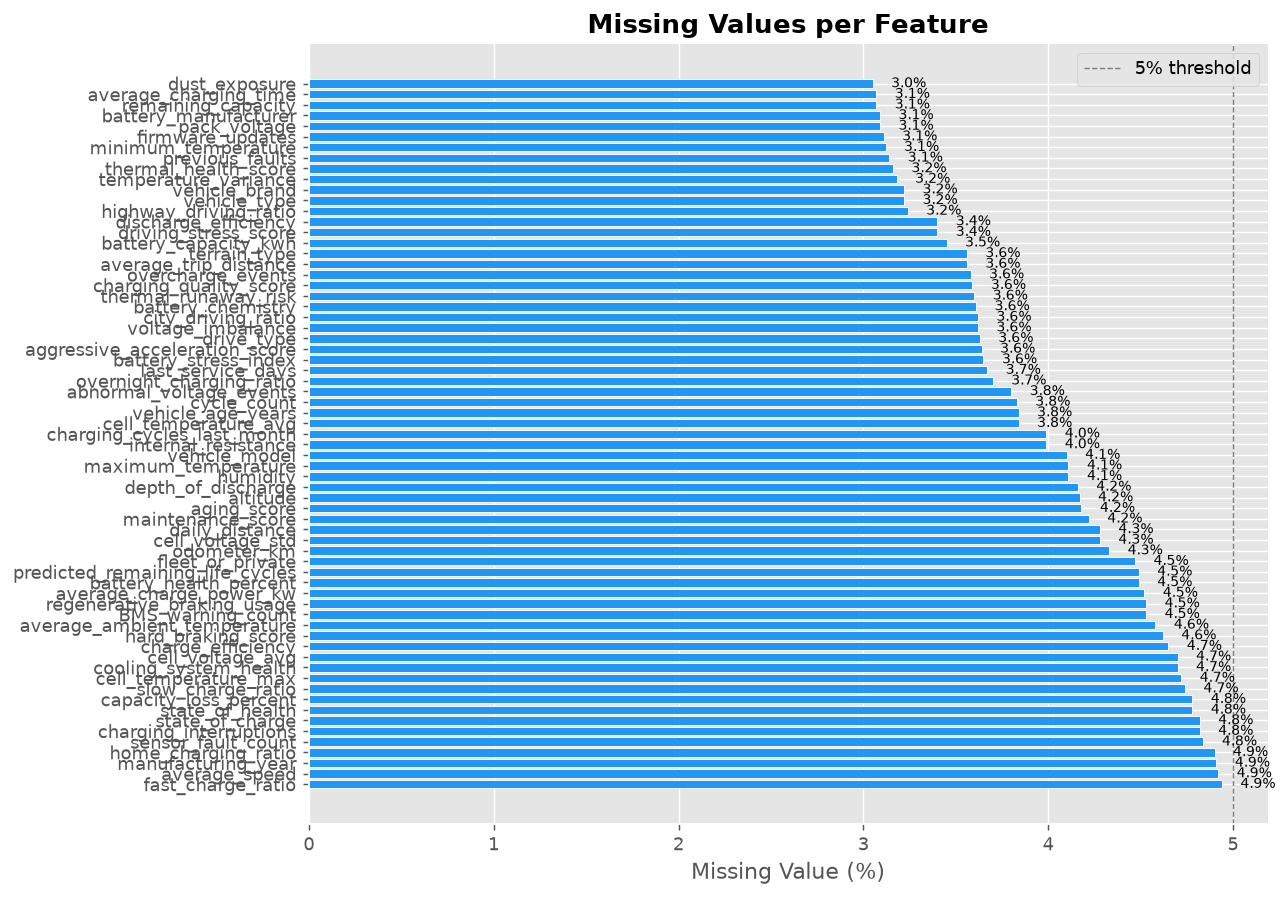

In [48]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[1] if p > 10 else PALETTE[0] for p in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor="white")
ax.axvline(5, color="gray", linestyle="--", linewidth=0.8, label="5% threshold")
ax.set_xlabel("Missing Value (%)")
ax.set_title("Missing Values per Feature", fontweight="bold")
ax.legend()
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(MODEL_DIR / "eda_missing_values.png", bbox_inches="tight")
plt.show()

### 3.3 Numerical Feature Distribution by Class

We inspect the top features most correlated with the target variable to understand the statistical separation between the Normal and Failure classes.

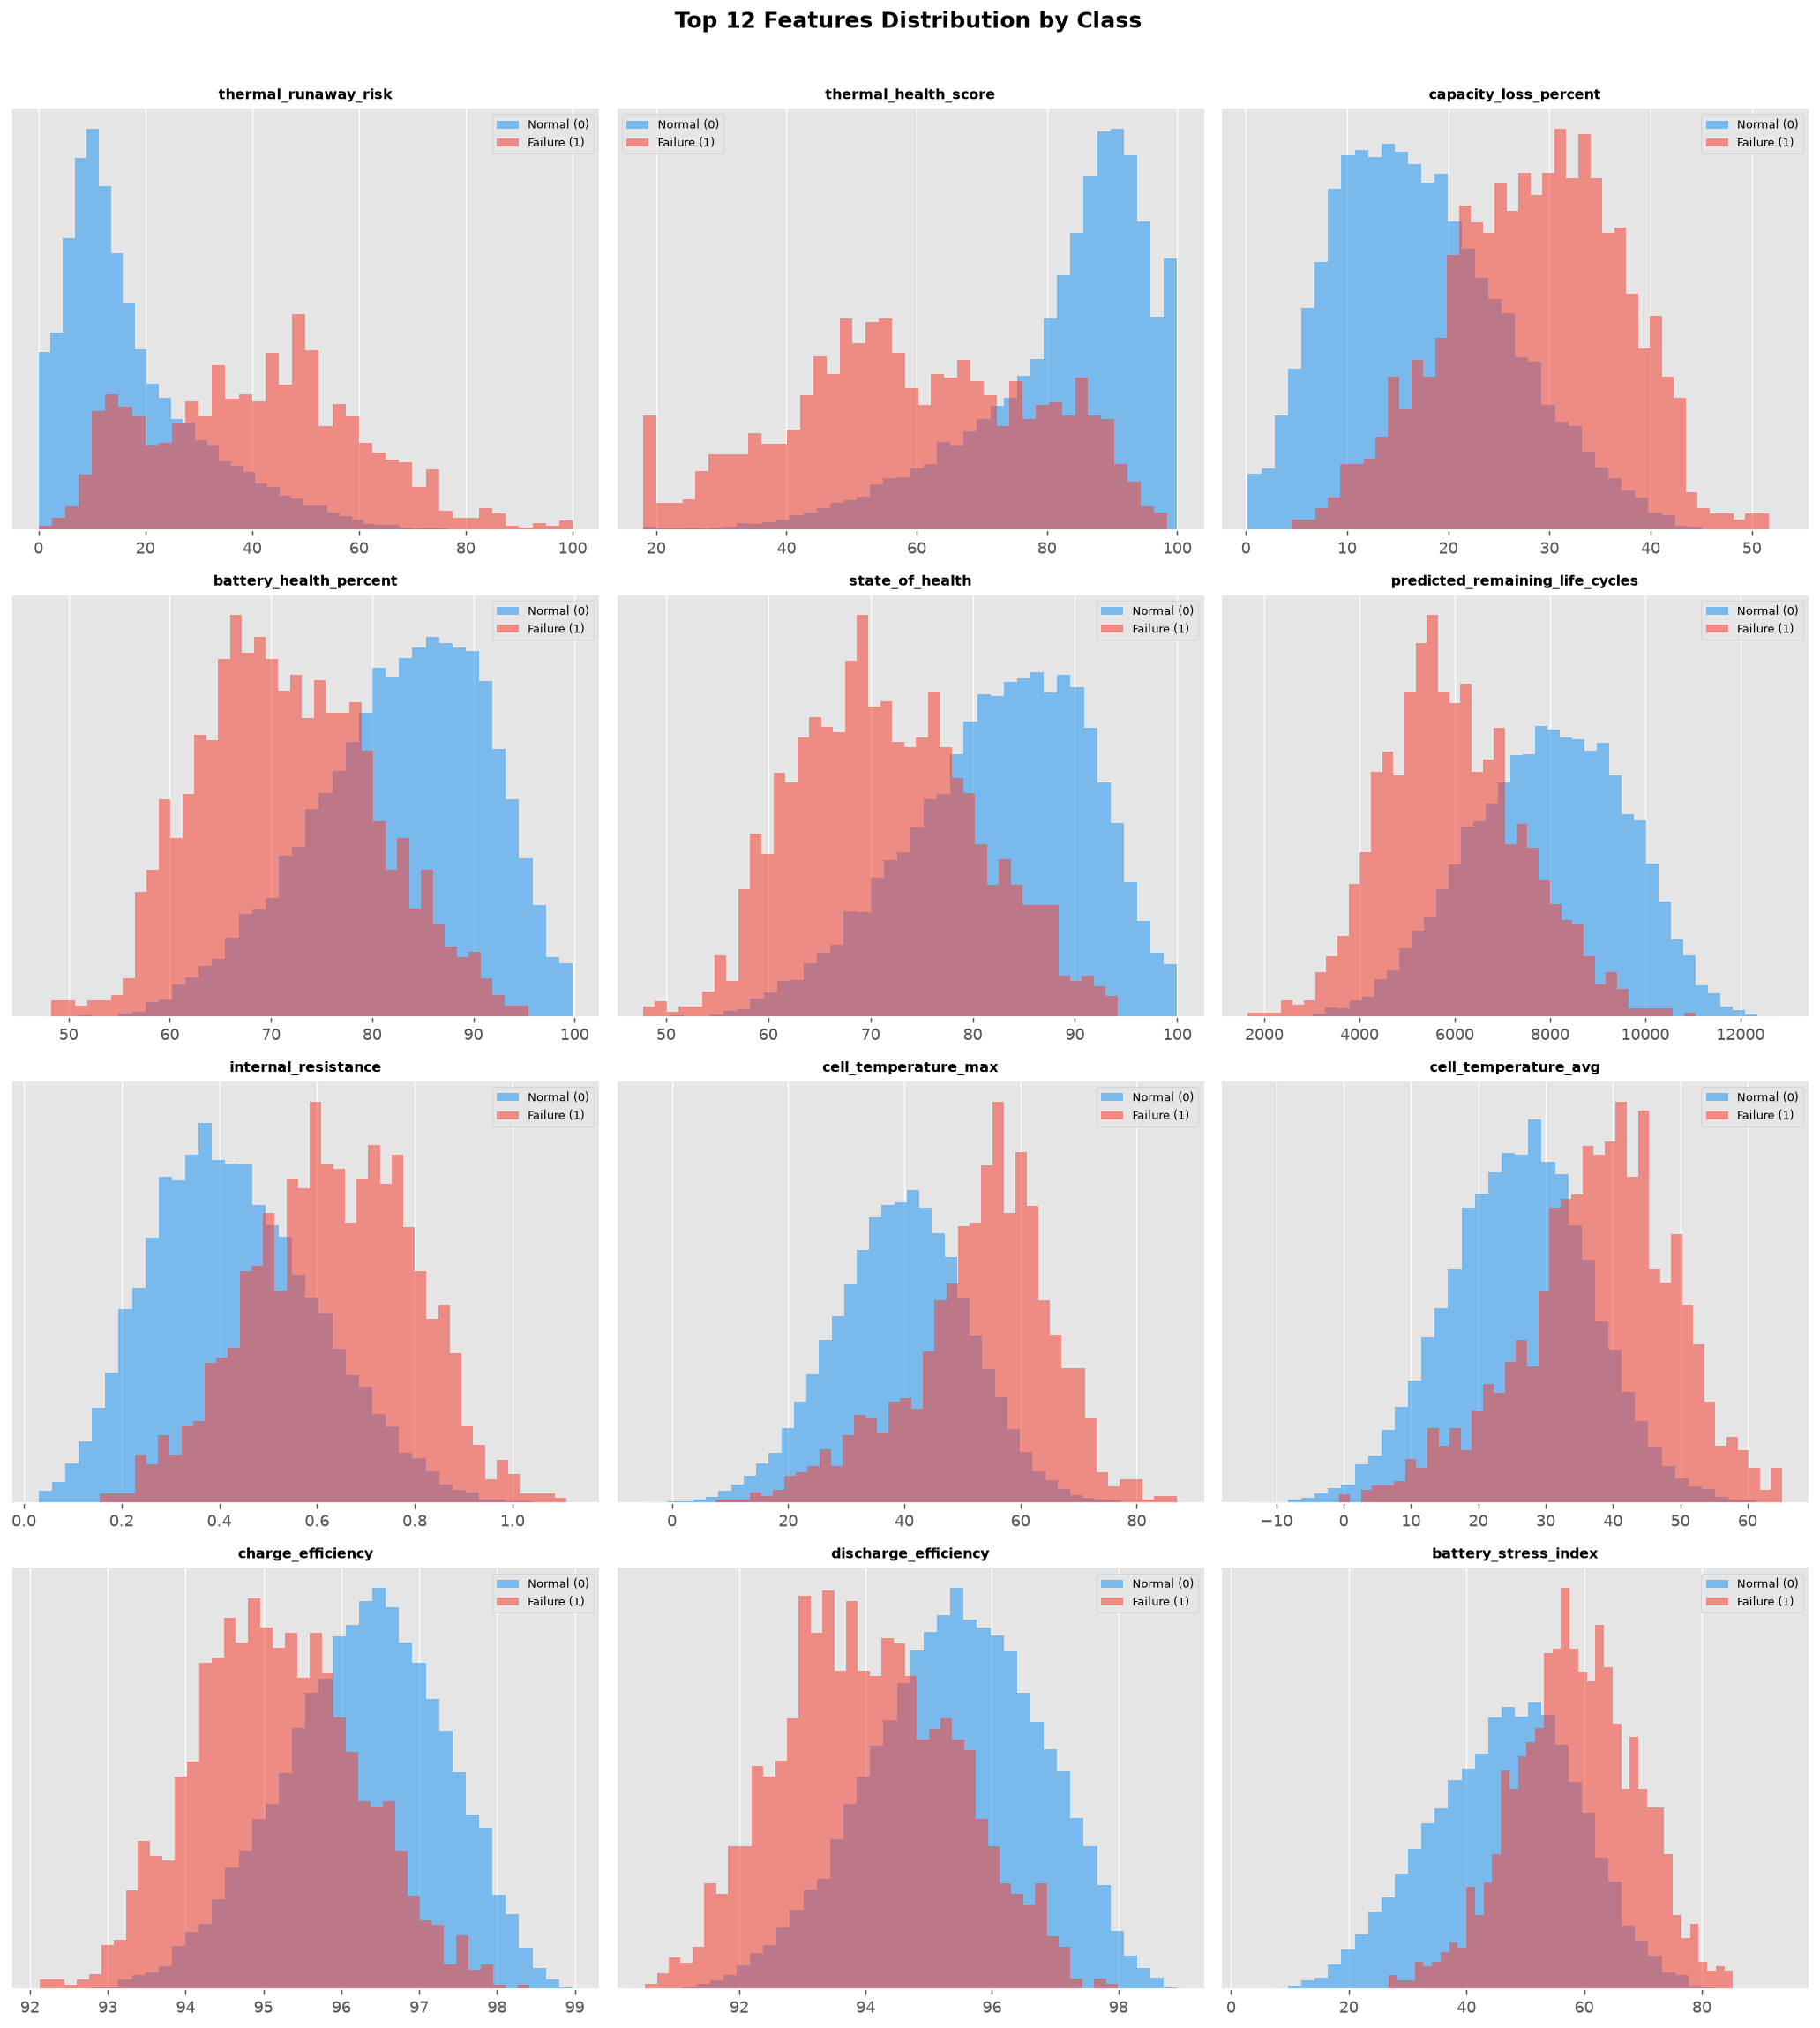

In [49]:
ID_COLS     = ["vehicle_id", "battery_serial"]
TARGET_COL  = "battery_failure"
CAT_COLS    = [
    "vehicle_brand", "vehicle_model", "vehicle_type",
    "battery_manufacturer", "battery_chemistry",
    "drive_type", "fleet_or_private", "terrain_type",
]
NUM_COLS = [
    c for c in df_raw.columns
    if c not in ID_COLS + [TARGET_COL] + CAT_COLS
]

corr_with_target = (
    df_raw[NUM_COLS + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=False)
)
TOP_N_FEATURES = corr_with_target.head(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(TOP_N_FEATURES):
    for label, color in zip([0, 1], PALETTE[:2]):
        subset = df_raw[df_raw[TARGET_COL] == label][col].dropna()
        axes[i].hist(
            subset, bins=40, alpha=0.55,
            color=color, edgecolor="none",
            label=f"{'Normal' if label == 0 else 'Failure'} ({label})",
            density=True,
        )
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=7)
    axes[i].set_yticks([])

plt.suptitle("Top 12 Features Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(MODEL_DIR / "eda_feature_distribution.png", bbox_inches="tight")
plt.show()

### 3.4 Correlation Heatmap (Top Features)

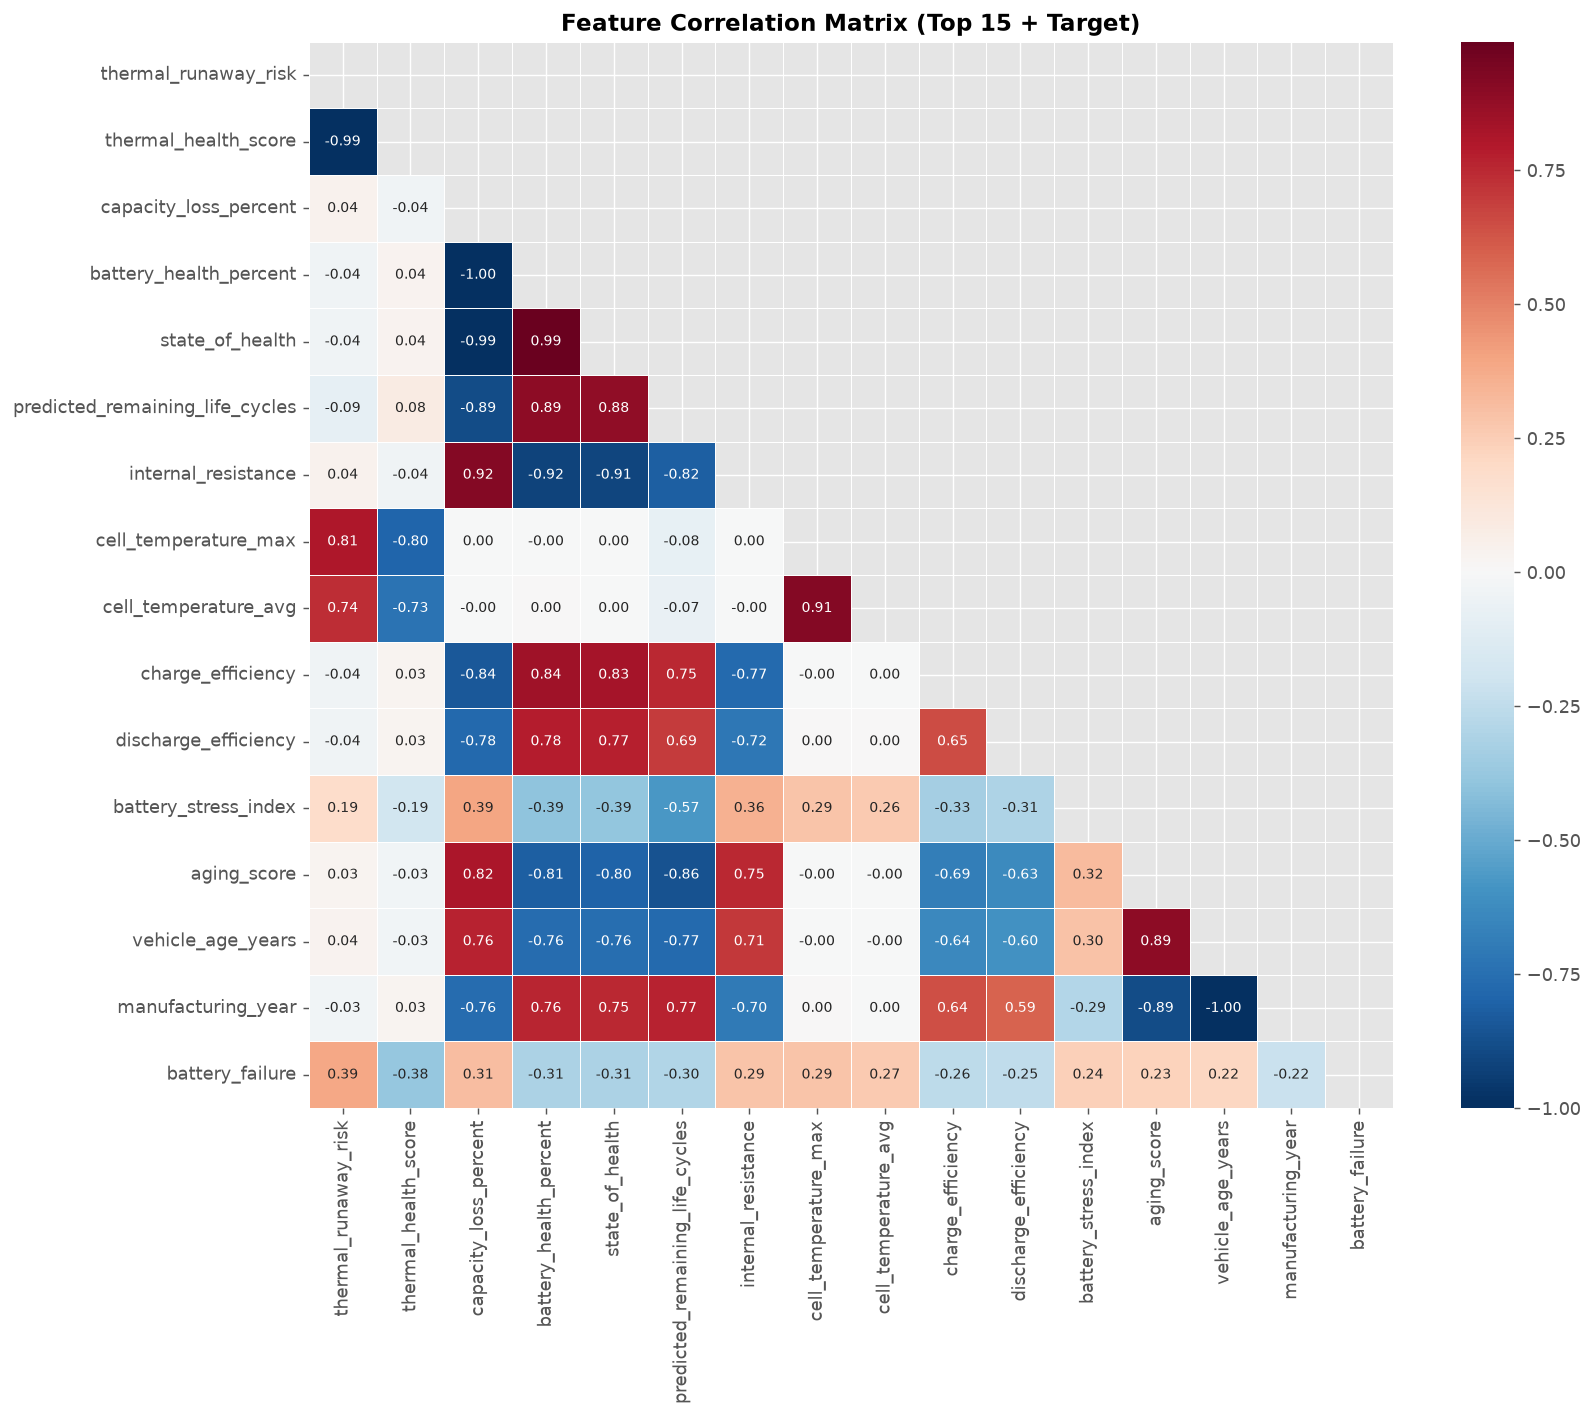

In [50]:
top_corr_features = corr_with_target.head(15).index.tolist()
corr_matrix = df_raw[top_corr_features + [TARGET_COL]].corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix (Top 15 + Target)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

---
## 4. Data Preprocessing

CatBoost natively handles:
- **Categorical features** — supplied through the `cat_features` parameter, no encoding needed.
- **Missing values (NaN)** — handled internally without explicit imputation.

The preprocessing steps below focus on:
1. Dropping identifier columns that carry no predictive value.
2. Ensuring categorical columns have a consistent string type (CatBoost requirement).
3. Splitting the data into stratified train/validation/test sets.

In [51]:
df = df_raw.drop(columns=ID_COLS).copy()

for col in CAT_COLS:
    df[col] = df[col].astype(str).replace("nan", np.nan)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"\nCategorical features ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Numerical features   ({len(NUM_COLS)}): {len(NUM_COLS)} columns")

Feature matrix shape : (20000, 67)
Target vector shape  : (20000,)

Categorical features (8): ['vehicle_brand', 'vehicle_model', 'vehicle_type', 'battery_manufacturer', 'battery_chemistry', 'drive_type', 'fleet_or_private', 'terrain_type']
Numerical features   (59): 59 columns


In [52]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15 / 0.85,
    stratify=y_train_val,
    random_state=SEED,
)

print("Data split summary:")
for name, y_split in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = y_split.value_counts()
    print(f"  {name:<12}: {len(y_split):>6,} rows  |  class 0 = {counts[0]:,}  |  class 1 = {counts.get(1, 0):,}")

Data split summary:
  Train       : 14,000 rows  |  class 0 = 13,032  |  class 1 = 968
  Validation  :  3,000 rows  |  class 0 = 2,792  |  class 1 = 208
  Test        :  3,000 rows  |  class 0 = 2,792  |  class 1 = 208


### 4.1 Handling Class Imbalance

The dataset exhibits a strong class imbalance with approximately a 13.5:1 ratio (Normal vs Failure). Two complementary strategies are used:

1. **SMOTE-NC (Synthetic Minority Over-sampling for Nominal and Continuous)**: Applied only on the training set to synthetically generate minority class samples. SMOTENC is chosen over standard SMOTE because the feature space contains a mix of numerical and categorical features.
2. **`scale_pos_weight` in CatBoost**: An additional class-weight penalty is passed to the model to further penalize misclassification of the minority class.

In [53]:
cat_indices = [X_train.columns.get_loc(c) for c in CAT_COLS if c in X_train.columns]
num_cols_train = [c for c in X_train.columns if c not in CAT_COLS]

num_medians = X_train[num_cols_train].median()

X_train_filled = X_train.copy()
for col in CAT_COLS:
    X_train_filled[col] = X_train_filled[col].fillna("Unknown")
for col in num_cols_train:
    X_train_filled[col] = X_train_filled[col].fillna(num_medians[col])

smotenc = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy=0.4,
    random_state=SEED,
    k_neighbors=5,
)

X_train_res_arr, y_train_res = smotenc.fit_resample(X_train_filled.values, y_train)
X_train_res = pd.DataFrame(X_train_res_arr, columns=X_train.columns)

for col in CAT_COLS:
    X_train_res[col] = X_train_res[col].astype(str)

for col in num_cols_train:
    X_train_res[col] = pd.to_numeric(X_train_res[col], errors='coerce')

for col in CAT_COLS:
    X_val[col]  = X_val[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

print("After SMOTE-NC resampling:")
print(f"  Total training samples : {len(y_train_res)}")
print(f"  Class 0 (Normal)       : {(y_train_res == 0).sum()}")
print(f"  Class 1 (Failure)      : {(y_train_res == 1).sum()}")
print(f"  scale_pos_weight       : {scale_pos_weight:.4f}")
print(f"  NaN in cat cols (train_res): {X_train_res[CAT_COLS].isnull().sum().sum()}")
print(f"  NaN in cat cols (val):       {X_val[CAT_COLS].isnull().sum().sum()}")
print(f"  NaN in cat cols (test):      {X_test[CAT_COLS].isnull().sum().sum()}")

After SMOTE-NC resampling:
  Total training samples : 18244
  Class 0 (Normal)       : 13032
  Class 1 (Failure)      : 5212
  scale_pos_weight       : 2.5004
  NaN in cat cols (train_res): 0
  NaN in cat cols (val):       0
  NaN in cat cols (test):      0


---
## 5. Feature Engineering

Beyond the raw features, a small set of domain-informed composite features is created based on the physical relationships between battery degradation signals. These aggregated signals are expected to carry stronger discriminative power than individual features.

In [54]:
def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()

    df_out["thermal_stress_composite"] = (
        df_out["cell_temperature_max"].fillna(df_out["cell_temperature_avg"]) -
        df_out["cell_temperature_avg"]
    )

    df_out["voltage_degradation_index"] = (
        df_out["internal_resistance"] * df_out["capacity_loss_percent"]
    )

    df_out["charge_discharge_efficiency_gap"] = (
        df_out["charge_efficiency"] - df_out["discharge_efficiency"]
    )

    df_out["health_decay_rate"] = (
        df_out["capacity_loss_percent"] / (df_out["vehicle_age_years"] + 1)
    )

    df_out["cycle_health_ratio"] = (
        df_out["battery_health_percent"] /
        (df_out["cycle_count"].astype(float) + 1)
    ) * 100

    df_out["fault_pressure_score"] = (
        df_out["sensor_fault_count"] +
        df_out["BMS_warning_count"].astype(float) +
        df_out["previous_faults"]
    )

    return df_out


ENGINEERED_FEATURES = [
    "thermal_stress_composite",
    "voltage_degradation_index",
    "charge_discharge_efficiency_gap",
    "health_decay_rate",
    "cycle_health_ratio",
    "fault_pressure_score",
]

X_train_res = engineer_features(X_train_res)
X_val       = engineer_features(X_val)
X_test      = engineer_features(X_test)

print(f"Engineered features added: {ENGINEERED_FEATURES}")
print(f"Total features after engineering: {X_train_res.shape[1]}")

Engineered features added: ['thermal_stress_composite', 'voltage_degradation_index', 'charge_discharge_efficiency_gap', 'health_decay_rate', 'cycle_health_ratio', 'fault_pressure_score']
Total features after engineering: 73


---
## 6. Baseline Model with Stratified K-Fold Cross-Validation

Before hyperparameter tuning, a baseline CatBoost model is evaluated using Stratified 5-Fold Cross-Validation on the resampled training set. This provides a stable, unbiased estimate of model performance and confirms the training configuration is sound.

In [55]:
cat_features_in_df = [c for c in CAT_COLS if c in X_train_res.columns]

baseline_params = {
    "iterations"         : 500,
    "learning_rate"      : 0.05,
    "depth"              : 6,
    "l2_leaf_reg"        : 3.0,
    "loss_function"      : "Logloss",
    "eval_metric"        : "AUC",
    "scale_pos_weight"   : scale_pos_weight,
    "cat_features"       : cat_features_in_df,
    "random_seed"        : SEED,
    "verbose"            : False,
    "early_stopping_rounds": 50,
    "task_type"          : "CPU",
    "thread_count"       : -1,
}

skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_roc_auc  = []
cv_pr_auc   = []
cv_f1       = []

for fold, (train_idx, oof_idx) in enumerate(skf.split(X_train_res, y_train_res), 1):
    X_f_train, X_f_oof = X_train_res.iloc[train_idx], X_train_res.iloc[oof_idx]
    y_f_train, y_f_oof = y_train_res.iloc[train_idx], y_train_res.iloc[oof_idx]

    model_cv = CatBoostClassifier(**baseline_params)
    model_cv.fit(
        X_f_train, y_f_train,
        eval_set=(X_f_oof, y_f_oof),
    )

    oof_proba = model_cv.predict_proba(X_f_oof)[:, 1]
    oof_pred  = (oof_proba >= 0.5).astype(int)

    roc = roc_auc_score(y_f_oof, oof_proba)
    pr  = average_precision_score(y_f_oof, oof_proba)
    f1  = f1_score(y_f_oof, oof_pred)

    cv_roc_auc.append(roc)
    cv_pr_auc.append(pr)
    cv_f1.append(f1)

    print(f"Fold {fold}  |  ROC-AUC: {roc:.4f}  |  PR-AUC: {pr:.4f}  |  F1: {f1:.4f}")

print(f"\nCV Summary:")
print(f"  ROC-AUC : {np.mean(cv_roc_auc):.4f} +/- {np.std(cv_roc_auc):.4f}")
print(f"  PR-AUC  : {np.mean(cv_pr_auc):.4f} +/- {np.std(cv_pr_auc):.4f}")
print(f"  F1 Score: {np.mean(cv_f1):.4f} +/- {np.std(cv_f1):.4f}")

Fold 1  |  ROC-AUC: 0.9963  |  PR-AUC: 0.9905  |  F1: 0.9580
Fold 2  |  ROC-AUC: 0.9974  |  PR-AUC: 0.9932  |  F1: 0.9673
Fold 3  |  ROC-AUC: 0.9978  |  PR-AUC: 0.9933  |  F1: 0.9666
Fold 4  |  ROC-AUC: 0.9970  |  PR-AUC: 0.9920  |  F1: 0.9580
Fold 5  |  ROC-AUC: 0.9968  |  PR-AUC: 0.9913  |  F1: 0.9571

CV Summary:
  ROC-AUC : 0.9971 +/- 0.0005
  PR-AUC  : 0.9921 +/- 0.0011
  F1 Score: 0.9614 +/- 0.0045


---
## 7. Hyperparameter Tuning with Optuna

Optuna performs **Tree-structured Parzen Estimator (TPE)** Bayesian optimization over the CatBoost hyperparameter search space. The objective is to maximize the **PR-AUC (Average Precision Score)** on the held-out validation set — the most appropriate metric for imbalanced binary classification tasks.

The search space covers depth, learning rate, regularization, tree count, and bagging parameters.

In [56]:
def objective(trial: optuna.trial.Trial) -> float:
    params = {
        "iterations"              : trial.suggest_int("iterations", 300, 1000),
        "learning_rate"           : trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth"                   : trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg"             : trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature"     : trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength"         : trial.suggest_float("random_strength", 0.0, 2.0),
        "border_count"            : trial.suggest_int("border_count", 32, 255),
        "loss_function"           : "Logloss",
        "eval_metric"             : "AUC",
        "scale_pos_weight"        : scale_pos_weight,
        "cat_features"            : cat_features_in_df,
        "random_seed"             : SEED,
        "verbose"                 : False,
        "early_stopping_rounds"   : 50,
        "task_type"               : "CPU",
        "thread_count"            : -1,
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train_res, y_train_res,
        eval_set=(X_val, y_val),
    )

    val_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, val_proba)


study = optuna.create_study(direction="maximize", study_name="catboost_ev_battery")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  PR-AUC : {study.best_value:.4f}")
print(f"  Params : {study.best_params}")

  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 34. Best value: 0.840917: 100%|██████████| 40/40 [1:08:21<00:00, 102.54s/it]


Best trial:
  PR-AUC : 0.8409
  Params : {'iterations': 806, 'learning_rate': 0.041707971572220025, 'depth': 9, 'l2_leaf_reg': 4.85022662862655, 'bagging_temperature': 0.9824688577947887, 'random_strength': 1.8255148917901884, 'border_count': 47}


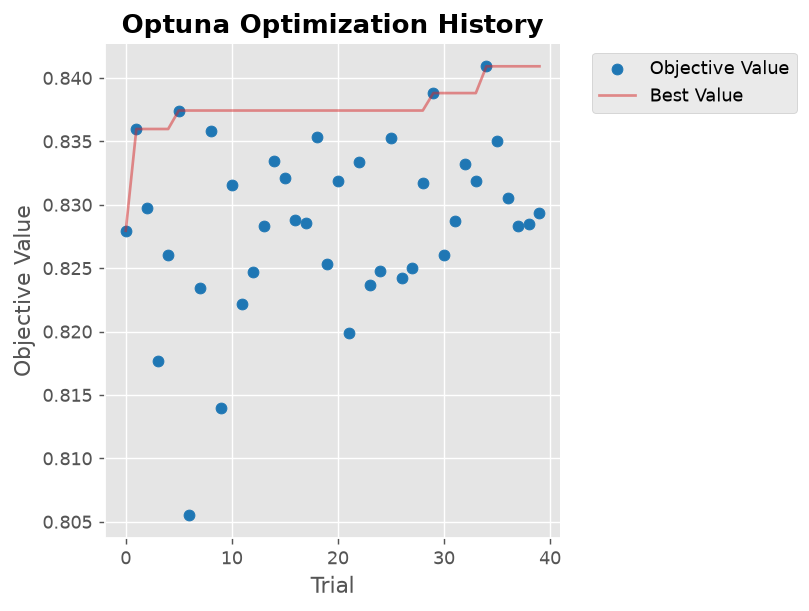

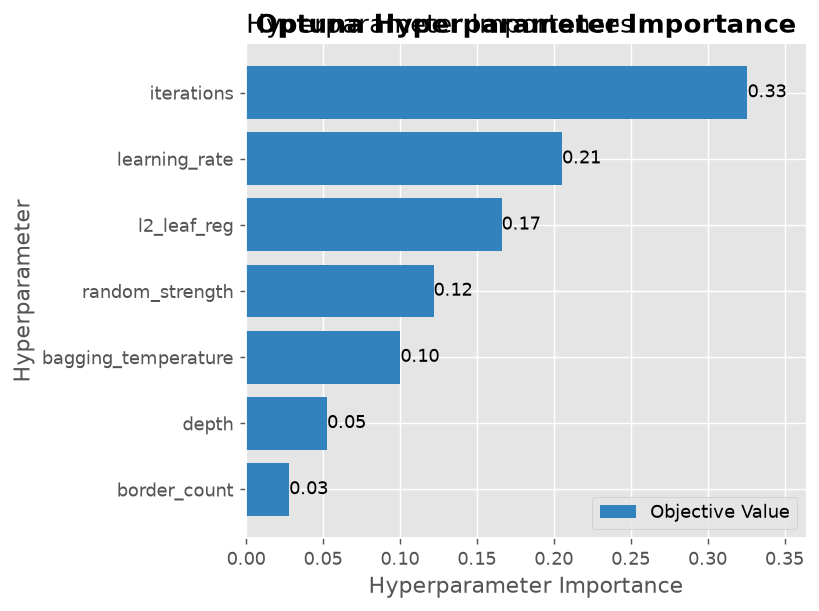

In [57]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History", fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "optuna_history.png", bbox_inches="tight")
plt.show()

fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Optuna Hyperparameter Importance", fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "optuna_param_importance.png", bbox_inches="tight")
plt.show()

---
## 8. Final Model Training

Using the best hyperparameters found by Optuna, the final CatBoost model is trained on the full resampled training set with the validation set used for early stopping.

In [58]:
best_params = study.best_params.copy()
best_params.update({
    "loss_function"         : "Logloss",
    "eval_metric"           : "AUC",
    "scale_pos_weight"      : scale_pos_weight,
    "cat_features"          : cat_features_in_df,
    "random_seed"           : SEED,
    "verbose"               : 100,
    "early_stopping_rounds" : 50,
    "task_type"             : "CPU",
    "thread_count"          : -1,
})

final_model = CatBoostClassifier(**best_params)
final_model.fit(
    X_train_res, y_train_res,
    eval_set=(X_val, y_val),
    plot=False,
)

print(f"\nBest iteration : {final_model.best_iteration_}")
print("Final model training complete.")

0:	test: 0.9391694	best: 0.9391694 (0)	total: 183ms	remaining: 2m 26s
100:	test: 0.9777868	best: 0.9777868 (100)	total: 16.6s	remaining: 1m 55s
200:	test: 0.9791230	best: 0.9792384 (175)	total: 32.1s	remaining: 1m 36s
300:	test: 0.9801734	best: 0.9801734 (300)	total: 48s	remaining: 1m 20s
400:	test: 0.9806418	best: 0.9807262 (393)	total: 1m 3s	remaining: 1m 4s
500:	test: 0.9810516	best: 0.9810671 (481)	total: 1m 20s	remaining: 48.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9814063533
bestIteration = 545

Shrink model to first 546 iterations.

Best iteration : 545
Final model training complete.


---
## 9. Model Evaluation

### 9.1 Optimal Threshold Selection

The default probability threshold of 0.50 is typically sub-optimal for imbalanced classification. We scan over all possible thresholds and select the one that maximizes the **F2-Score** — which deliberately weighs Recall twice as heavily as Precision. In battery failure detection, a missed failure (false negative) is far more costly than a false alarm (false positive).

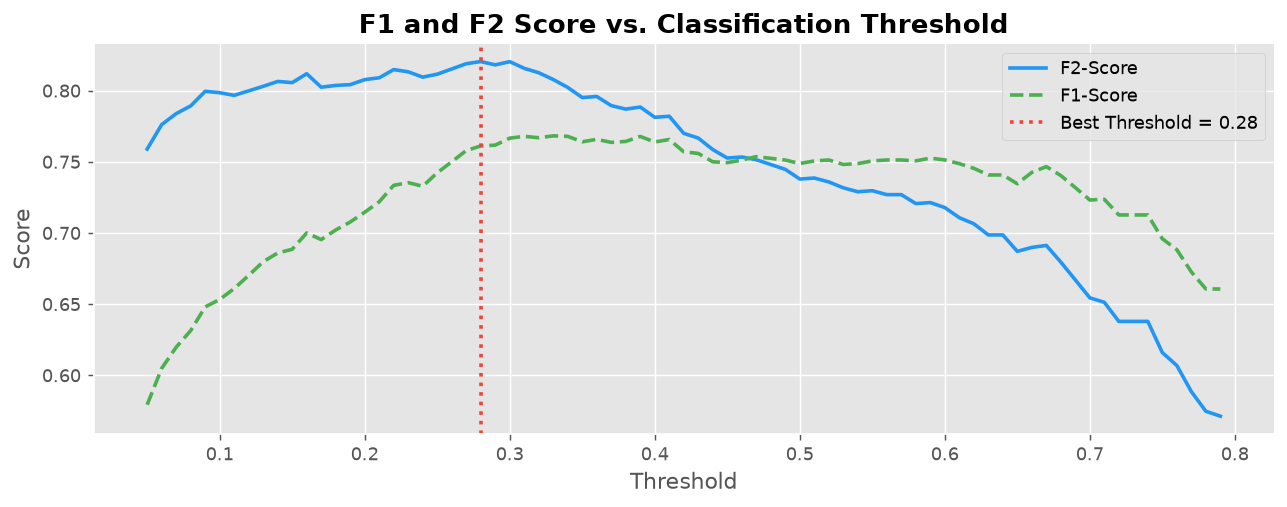

Optimal threshold (max F2-Score): 0.28
F2-Score at optimal threshold   : 0.8204


In [59]:
val_proba = final_model.predict_proba(X_val)[:, 1]

thresholds    = np.arange(0.05, 0.80, 0.01)
f2_scores     = []
f1_scores_thr = []

for thr in thresholds:
    preds = (val_proba >= thr).astype(int)
    f2 = fbeta_score(y_val, preds, beta=2, zero_division=0)
    f1 = f1_score(y_val, preds, zero_division=0)
    f2_scores.append(f2)
    f1_scores_thr.append(f1)

best_thr_idx  = np.argmax(f2_scores)
BEST_THRESHOLD = thresholds[best_thr_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f2_scores, label="F2-Score", color=PALETTE[0], linewidth=2)
ax.plot(thresholds, f1_scores_thr, label="F1-Score", color=PALETTE[2], linewidth=2, linestyle="--")
ax.axvline(BEST_THRESHOLD, color=PALETTE[1], linestyle=":", linewidth=2, label=f"Best Threshold = {BEST_THRESHOLD:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("F1 and F2 Score vs. Classification Threshold", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "eval_threshold_selection.png", bbox_inches="tight")
plt.show()

print(f"Optimal threshold (max F2-Score): {BEST_THRESHOLD:.2f}")
print(f"F2-Score at optimal threshold   : {f2_scores[best_thr_idx]:.4f}")

### 9.2 Test Set Evaluation

In [60]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= BEST_THRESHOLD).astype(int)

roc_auc  = roc_auc_score(y_test, test_proba)
pr_auc   = average_precision_score(y_test, test_proba)
f1_test  = f1_score(y_test, test_pred)
f2_test  = fbeta_score(y_test, test_pred, beta=2)

print("Test Set Evaluation Metrics")
print("-" * 40)
print(f"ROC-AUC Score     : {roc_auc:.4f}")
print(f"PR-AUC Score      : {pr_auc:.4f}")
print(f"F1 Score          : {f1_test:.4f}")
print(f"F2 Score          : {f2_test:.4f}")
print(f"Threshold Used    : {BEST_THRESHOLD:.2f}")
print("-" * 40)
print("\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=["Normal (0)", "Failure (1)"]))

Test Set Evaluation Metrics
----------------------------------------
ROC-AUC Score     : 0.9773
PR-AUC Score      : 0.7644
F1 Score          : 0.7231
F2 Score          : 0.7897
Threshold Used    : 0.28
----------------------------------------

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.96      0.98      2792
 Failure (1)       0.63      0.84      0.72       208

    accuracy                           0.96      3000
   macro avg       0.81      0.90      0.85      3000
weighted avg       0.96      0.96      0.96      3000



### 9.3 ROC Curve and Precision-Recall Curve

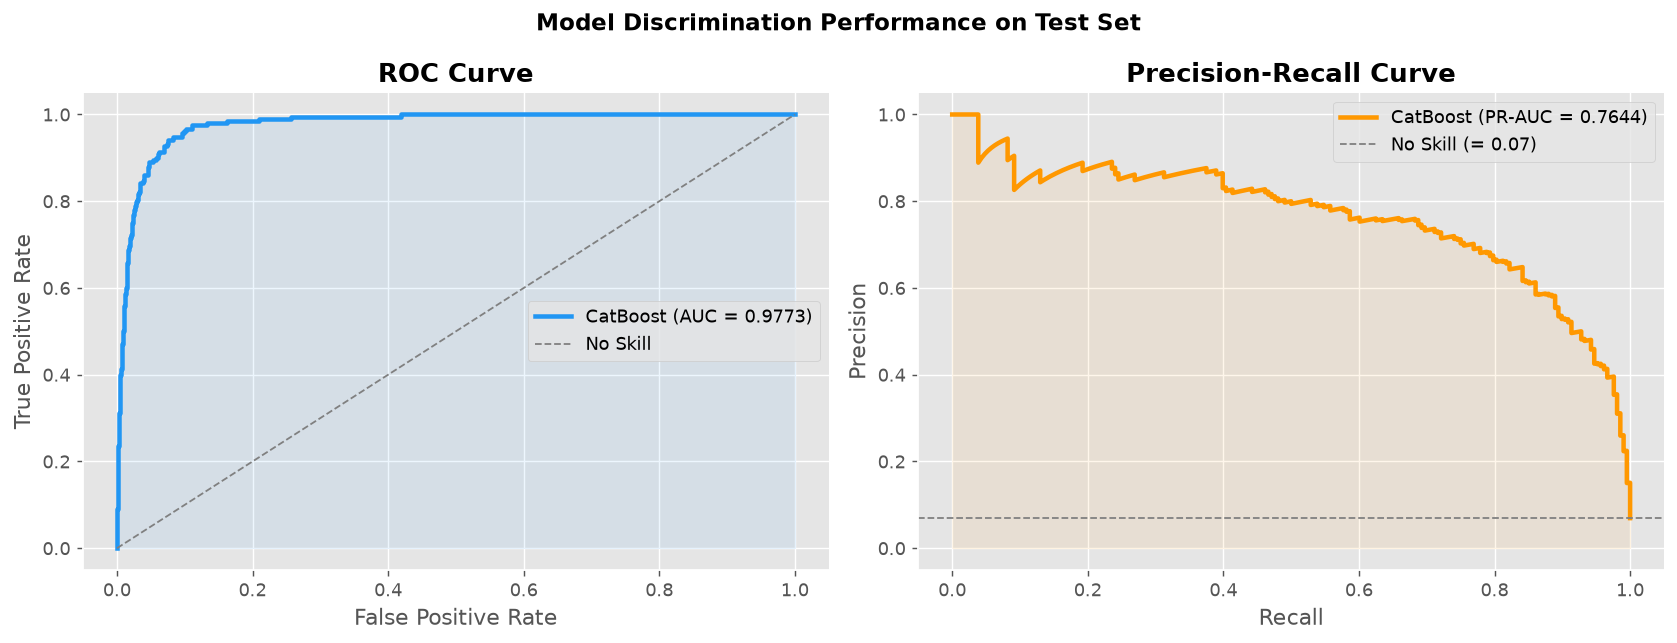

In [61]:
fpr, tpr, _  = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)
no_skill_pr  = y_test.sum() / len(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color=PALETTE[0], linewidth=2.5, label=f"CatBoost (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="No Skill")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend()
axes[0].fill_between(fpr, tpr, alpha=0.08, color=PALETTE[0])

axes[1].plot(rec, prec, color=PALETTE[3], linewidth=2.5, label=f"CatBoost (PR-AUC = {pr_auc:.4f})")
axes[1].axhline(no_skill_pr, linestyle="--", color="gray", linewidth=1, label=f"No Skill (= {no_skill_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].legend()
axes[1].fill_between(rec, prec, alpha=0.08, color=PALETTE[3])

plt.suptitle("Model Discrimination Performance on Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "eval_roc_pr_curves.png", bbox_inches="tight")
plt.show()

### 9.4 Confusion Matrix

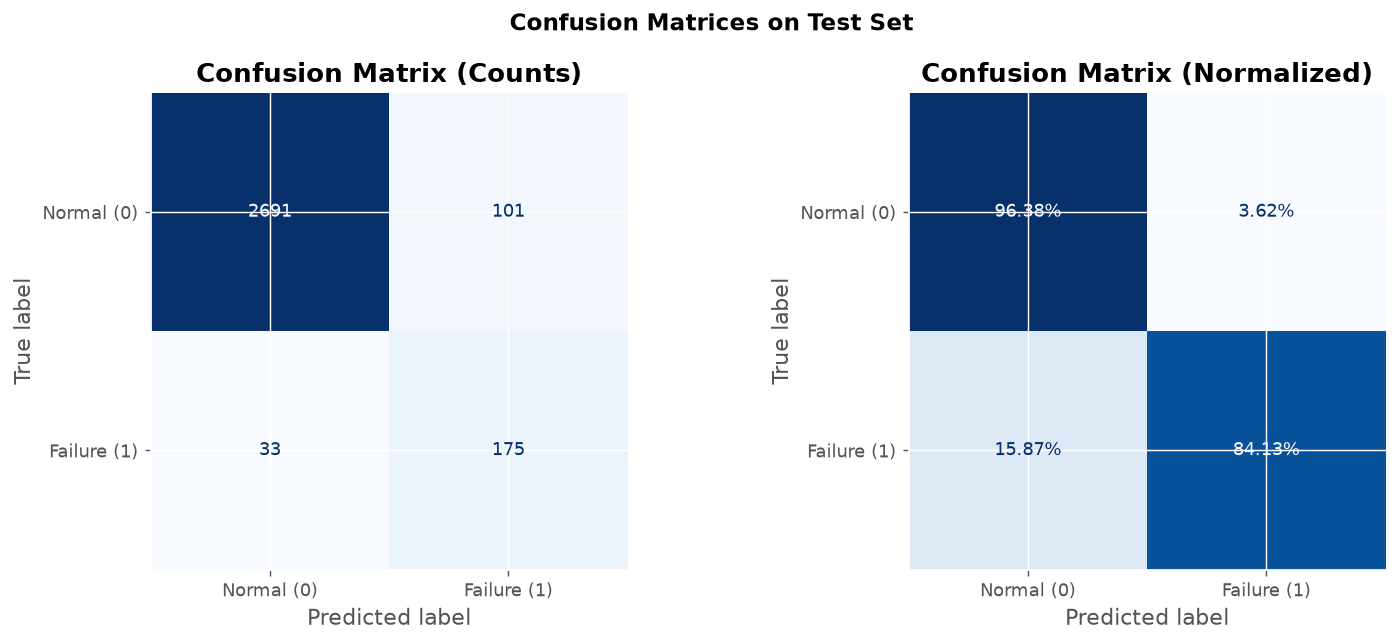

True Positives  (TP): 175   — Failures correctly detected
False Negatives (FN): 33   — Failures missed (most critical error)
False Positives (FP): 101  — Normal batteries flagged incorrectly
True Negatives  (TN): 2,691 — Normal batteries correctly classified


In [62]:
cm = confusion_matrix(y_test, test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm, display_labels=["Normal (0)", "Failure (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=["Normal (0)", "Failure (1)"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2%"
)
axes[1].set_title("Confusion Matrix (Normalized)", fontweight="bold")

plt.suptitle("Confusion Matrices on Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "eval_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (TP): {tp}   — Failures correctly detected")
print(f"False Negatives (FN): {fn}   — Failures missed (most critical error)")
print(f"False Positives (FP): {fp}  — Normal batteries flagged incorrectly")
print(f"True Negatives  (TN): {tn:,} — Normal batteries correctly classified")

---
## 10. Feature Importance and SHAP Analysis

### 10.1 CatBoost Built-in Feature Importance

CatBoost provides native feature importance scores based on how frequently each feature is used in splits and how much it improves the loss at each split.

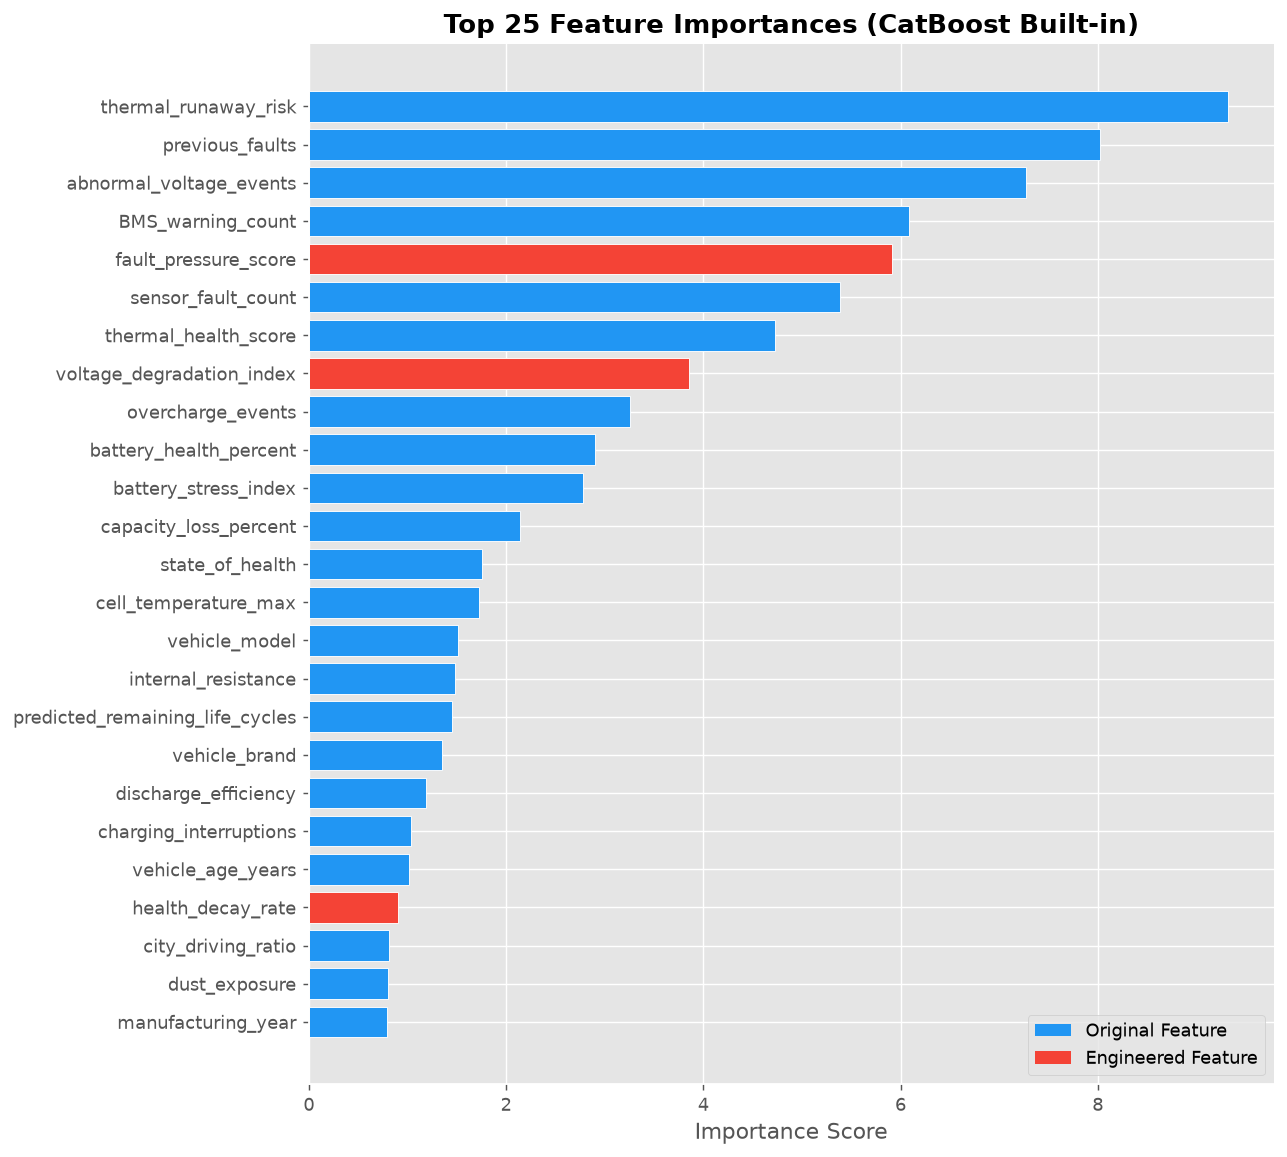

In [63]:
feat_imp = pd.Series(
    final_model.get_feature_importance(),
    index=X_train_res.columns,
).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 9))
colors_imp = [PALETTE[1] if col in ENGINEERED_FEATURES else PALETTE[0] for col in feat_imp.index]
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors_imp[::-1], edgecolor="white")
ax.set_xlabel("Importance Score")
ax.set_title("Top 25 Feature Importances (CatBoost Built-in)", fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[0], label="Original Feature"),
    Patch(facecolor=PALETTE[1], label="Engineered Feature"),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(MODEL_DIR / "eval_feature_importance.png", bbox_inches="tight")
plt.show()

### 10.2 SHAP Summary Plot

SHAP (SHapley Additive exPlanations) provides a theoretically grounded, game-theory-based framework for explaining individual model predictions. The beeswarm plot below shows how each feature affects the model output: the x-axis represents the SHAP value (impact on log-odds of failure), while color represents the feature value magnitude.

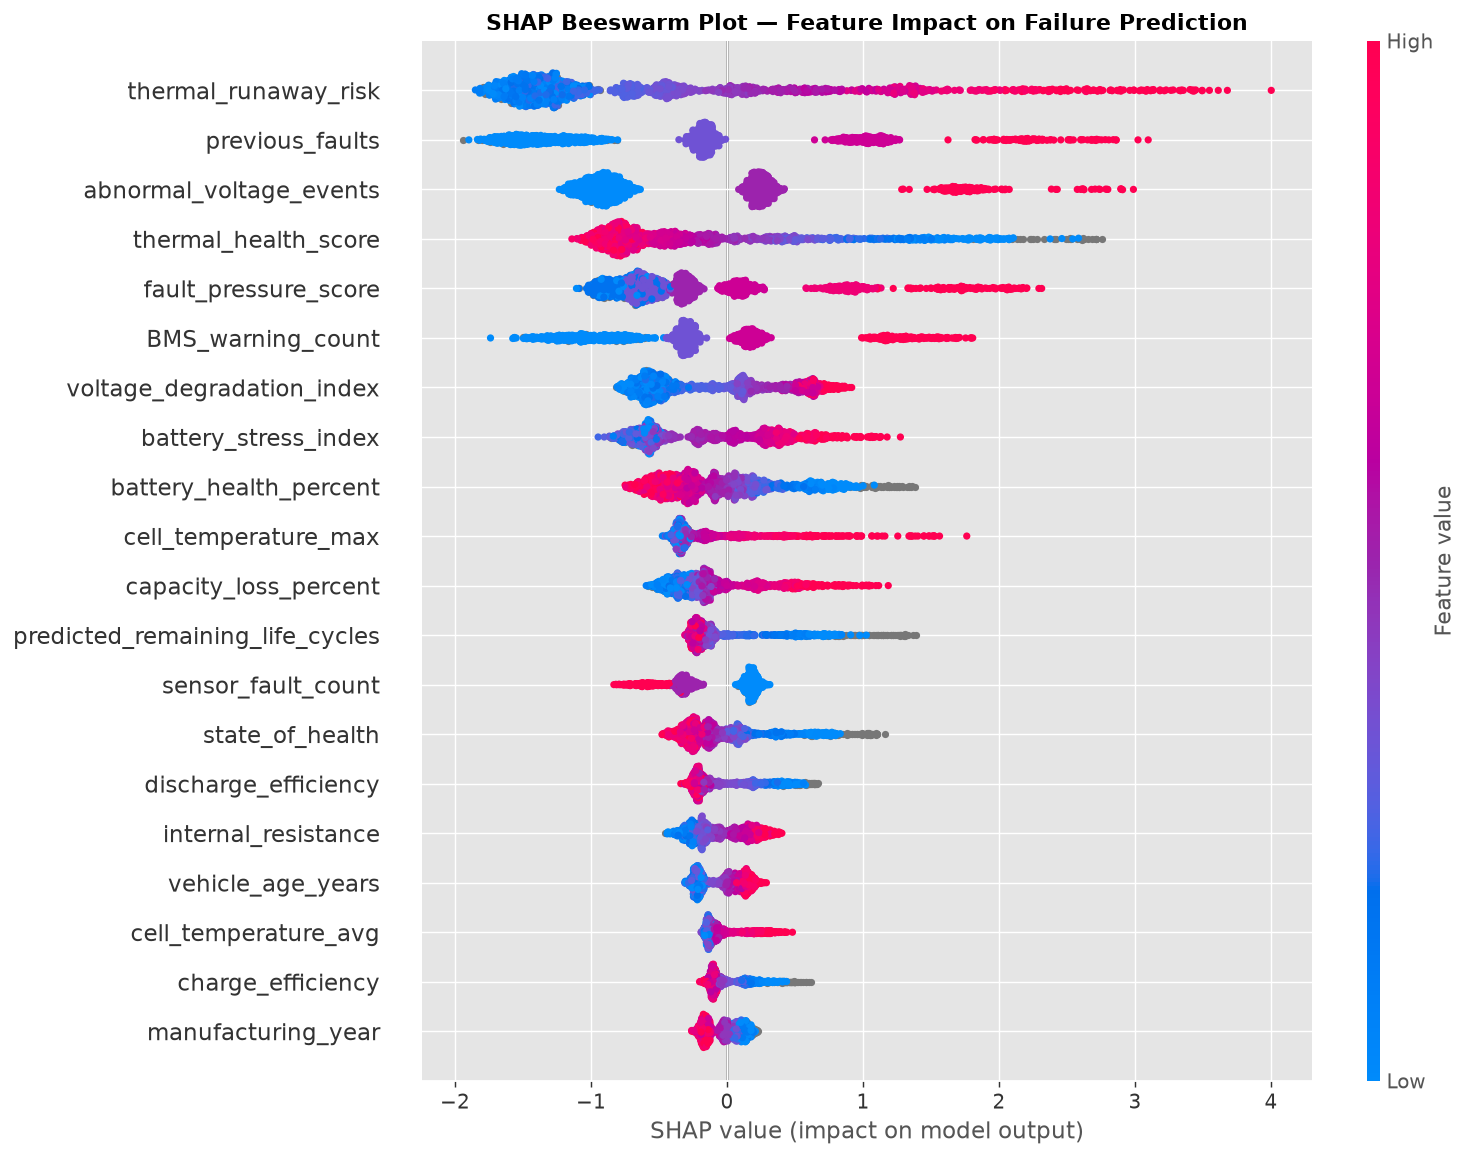

In [64]:
sample_size = min(1500, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=SEED)

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,
    show=False,
    plot_size=None,
)
plt.title("SHAP Beeswarm Plot — Feature Impact on Failure Prediction", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / "shap_beeswarm.png", bbox_inches="tight")
plt.show()

### 10.3 SHAP Bar Plot (Mean Absolute SHAP)

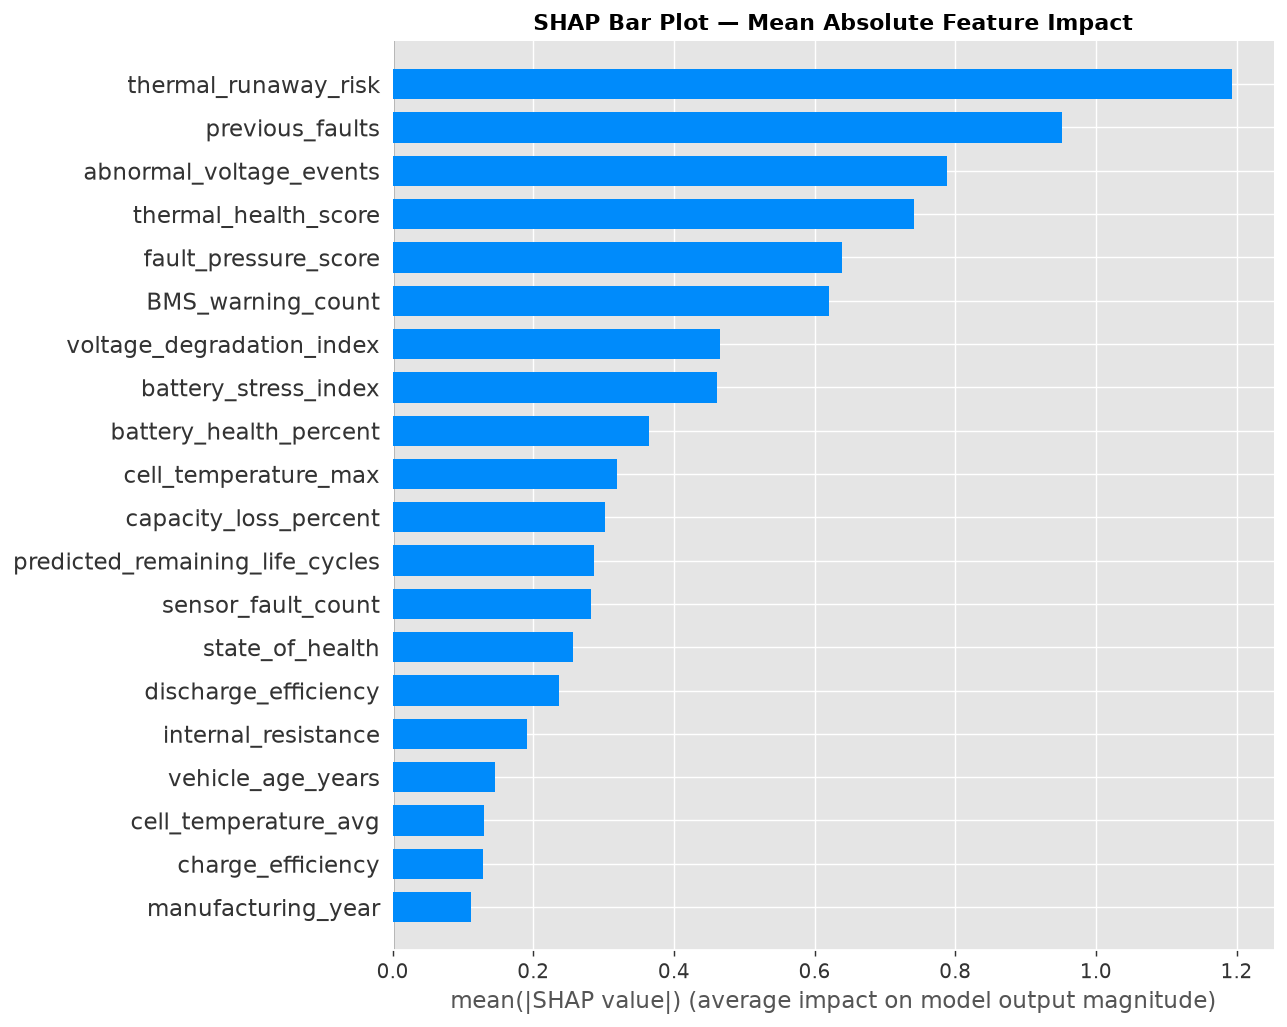

In [65]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    max_display=20,
    show=False,
    plot_size=None,
)
plt.title("SHAP Bar Plot — Mean Absolute Feature Impact", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / "shap_bar.png", bbox_inches="tight")
plt.show()

---
## 11. Inference Pipeline

The inference function below encapsulates the complete prediction workflow: feature engineering, probability estimation, and threshold-based binary classification. It accepts a raw input `DataFrame` (matching the structure of the original dataset, without ID columns) and returns a structured prediction result.

In [66]:
def predict_battery_failure(
    input_df: pd.DataFrame,
    model: CatBoostClassifier,
    threshold: float = BEST_THRESHOLD,
    cat_cols: list = CAT_COLS,
    id_cols: list = ID_COLS,
) -> pd.DataFrame:

    df_infer = input_df.copy()

    drop_cols = [c for c in id_cols + [TARGET_COL] if c in df_infer.columns]
    df_infer = df_infer.drop(columns=drop_cols, errors="ignore")

    for col in cat_cols:
        if col in df_infer.columns:
            df_infer[col] = df_infer[col].fillna("Unknown").astype(str)

    df_infer = engineer_features(df_infer)

    proba  = model.predict_proba(df_infer)[:, 1]
    labels = (proba >= threshold).astype(int)

    result = pd.DataFrame({
        "failure_probability"  : proba.round(4),
        "predicted_failure"    : labels,
        "risk_level"           : pd.cut(
            proba,
            bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
            labels=["Very Low", "Low", "Medium", "High", "Critical"],
        ),
    })

    return result


print("Inference function defined.")

Inference function defined.


In [67]:
sample_input = df_raw.drop(columns=[TARGET_COL]).sample(10, random_state=SEED)

inference_results = predict_battery_failure(sample_input, final_model)

print("Inference Results on 10 Random Samples:")
print(inference_results.to_string())

Inference Results on 10 Random Samples:
   failure_probability  predicted_failure risk_level
0               0.0087                  0   Very Low
1               0.0001                  0   Very Low
2               0.7842                  1       High
3               0.0000                  0   Very Low
4               0.0013                  0   Very Low
5               0.0112                  0   Very Low
6               0.0016                  0   Very Low
7               0.0018                  0   Very Low
8               0.0010                  0   Very Low
9               0.7495                  1       High


#### Single Sample Inference Example

The block below demonstrates how to construct a minimal input dictionary from domain knowledge and run a prediction on a single vehicle — simulating a real-time API call scenario.

In [68]:
single_sample = pd.DataFrame([{
    "vehicle_brand"                 : "BYD",
    "vehicle_model"                 : "Atto 3",
    "vehicle_type"                  : "Sedan",
    "manufacturing_year"            : 2019,
    "battery_manufacturer"          : "CATL",
    "battery_chemistry"             : "NMC",
    "battery_capacity_kwh"          : 75.0,
    "drive_type"                    : "AWD",
    "odometer_km"                   : 210000.0,
    "vehicle_age_years"             : 7.0,
    "fleet_or_private"              : "Fleet",
    "cycle_count"                   : 1850,
    "battery_health_percent"        : 65.0,
    "state_of_charge"               : 30.0,
    "depth_of_discharge"            : 72.0,
    "state_of_health"               : 63.5,
    "cell_voltage_avg"              : 3.65,
    "cell_voltage_std"              : 0.045,
    "pack_voltage"                  : 340.0,
    "cell_temperature_avg"          : 44.0,
    "cell_temperature_max"          : 58.0,
    "internal_resistance"           : 0.95,
    "charge_efficiency"             : 91.5,
    "discharge_efficiency"          : 90.2,
    "remaining_capacity"            : 48.75,
    "capacity_loss_percent"         : 35.0,
    "charging_cycles_last_month"    : 22,
    "fast_charge_ratio"             : 0.68,
    "slow_charge_ratio"             : 0.32,
    "average_charge_power_kw"       : 62.0,
    "average_charging_time"         : 145.0,
    "overnight_charging_ratio"      : 0.28,
    "home_charging_ratio"           : 0.35,
    "charging_interruptions"        : 4,
    "overcharge_events"             : 3,
    "average_speed"                 : 85.0,
    "average_trip_distance"         : 55.0,
    "aggressive_acceleration_score" : 72.0,
    "hard_braking_score"            : 68.0,
    "regenerative_braking_usage"    : 30.0,
    "highway_driving_ratio"         : 0.6,
    "city_driving_ratio"            : 0.4,
    "daily_distance"                : 130.0,
    "average_ambient_temperature"   : 38.5,
    "maximum_temperature"           : 52.0,
    "minimum_temperature"           : 28.0,
    "humidity"                      : 55.0,
    "altitude"                      : 500.0,
    "terrain_type"                  : "Hilly",
    "dust_exposure"                 : 65.0,
    "last_service_days"             : 480.0,
    "cooling_system_health"         : 72.0,
    "firmware_updates"              : 2,
    "previous_faults"               : 5,
    "maintenance_score"             : 45.0,
    "thermal_runaway_risk"          : 0.72,
    "voltage_imbalance"             : 38.0,
    "temperature_variance"          : 14.0,
    "sensor_fault_count"            : 3,
    "BMS_warning_count"             : 8,
    "abnormal_voltage_events"       : 4,
    "battery_stress_index"          : 78.0,
    "aging_score"                   : 85.0,
    "thermal_health_score"          : 42.0,
    "charging_quality_score"        : 55.0,
    "driving_stress_score"          : 69.0,
    "predicted_remaining_life_cycles": 1200,
}])

single_result = predict_battery_failure(single_sample, final_model)

print("Single Vehicle Inference:")
print(f"  Failure Probability : {single_result['failure_probability'].values[0]:.4f}")
print(f"  Predicted Failure   : {'YES — Battery Failure Detected' if single_result['predicted_failure'].values[0] == 1 else 'NO — Battery Normal'}")
print(f"  Risk Level          : {single_result['risk_level'].values[0]}")

Single Vehicle Inference:
  Failure Probability : 0.9939
  Predicted Failure   : YES — Battery Failure Detected
  Risk Level          : Critical


---
## 12. Model Persistence

All model artifacts, metadata, and evaluation metrics are saved to the `saved_models/` directory for reproducibility, deployment, and future reuse. The saved artifacts include:

| Artifact | Format | Description |
|---|---|---|
| `catboost_model.cbm` | CatBoost native | Full trained model with internal parameters |
| `catboost_model.pkl` | Pickle | Alternative Python-serialized model |
| `model_metadata.json` | JSON | Hyperparameters, threshold, feature lists, and evaluation metrics |
| `feature_columns.pkl` | Pickle | Ordered list of feature columns for inference alignment |

In [69]:
cbm_path      = MODEL_DIR / "catboost_model.cbm"
pkl_path      = MODEL_DIR / "catboost_model.pkl"
metadata_path = MODEL_DIR / "model_metadata.json"
features_path = MODEL_DIR / "feature_columns.pkl"

final_model.save_model(str(cbm_path))

with open(pkl_path, "wb") as f:
    pickle.dump(final_model, f)

with open(features_path, "wb") as f:
    pickle.dump(X_train_res.columns.tolist(), f)

metadata = {
    "model_name"            : "CatBoostClassifier",
    "task"                  : "Binary Classification — EV Battery Failure",
    "target_column"         : TARGET_COL,
    "best_threshold"        : float(BEST_THRESHOLD),
    "best_iteration"        : int(final_model.best_iteration_),
    "hyperparameters"       : {k: v for k, v in best_params.items() if k != "cat_features"},
    "scale_pos_weight"      : float(scale_pos_weight),
    "cat_features"          : cat_features_in_df,
    "engineered_features"   : ENGINEERED_FEATURES,
    "id_columns_dropped"    : ID_COLS,
    "total_features"        : int(X_train_res.shape[1]),
    "train_samples"         : int(len(X_train_res)),
    "test_samples"          : int(len(X_test)),
    "evaluation_metrics": {
        "roc_auc"           : float(round(roc_auc, 4)),
        "pr_auc"            : float(round(pr_auc, 4)),
        "f1_score"          : float(round(f1_test, 4)),
        "f2_score"          : float(round(f2_test, 4)),
    },
    "confusion_matrix": {
        "TP": int(tp), "FP": int(fp),
        "FN": int(fn), "TN": int(tn),
    },
    "cv_results": {
        "roc_auc_mean"  : float(round(np.mean(cv_roc_auc), 4)),
        "roc_auc_std"   : float(round(np.std(cv_roc_auc), 4)),
        "pr_auc_mean"   : float(round(np.mean(cv_pr_auc), 4)),
        "pr_auc_std"    : float(round(np.std(cv_pr_auc), 4)),
    },
    "smotenc_sampling_strategy" : 0.4,
    "optuna_n_trials"           : 40,
    "random_seed"               : SEED,
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Model artifacts saved:")
for path in [cbm_path, pkl_path, metadata_path, features_path]:
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:<30}  {size_kb:>8.1f} KB")

Model artifacts saved:
  catboost_model.cbm                4715.1 KB
  catboost_model.pkl                4743.5 KB
  model_metadata.json                  1.9 KB
  feature_columns.pkl                  1.5 KB


---
## 13. Loading and Using the Saved Model

This section demonstrates how to load the persisted model in a separate environment (e.g., a deployment server or a different notebook) and run inference without requiring the full training pipeline to be re-executed.

In [70]:
loaded_model = CatBoostClassifier()
loaded_model.load_model(str(cbm_path))

with open(features_path, "rb") as f:
    saved_feature_columns = pickle.load(f)

with open(metadata_path, "r") as f:
    saved_metadata = json.load(f)

loaded_threshold = saved_metadata["best_threshold"]

print("Model loaded successfully from disk.")
print(f"Expected features   : {len(saved_feature_columns)}")
print(f"Best threshold      : {loaded_threshold}")
print(f"Evaluation metrics  : {saved_metadata['evaluation_metrics']}")

Model loaded successfully from disk.
Expected features   : 73
Best threshold      : 0.28
Evaluation metrics  : {'roc_auc': 0.9773, 'pr_auc': 0.7644, 'f1_score': 0.7231, 'f2_score': 0.7897}


In [71]:
verify_proba = loaded_model.predict_proba(X_test)[:, 1]
verify_pred  = (verify_proba >= loaded_threshold).astype(int)

verify_roc = roc_auc_score(y_test, verify_proba)
verify_f1  = f1_score(y_test, verify_pred)

print("Loaded Model Verification on Test Set:")
print(f"  ROC-AUC : {verify_roc:.4f}  (expected: {saved_metadata['evaluation_metrics']['roc_auc']})")
print(f"  F1 Score: {verify_f1:.4f}  (expected: {saved_metadata['evaluation_metrics']['f1_score']})")
assert abs(verify_roc - saved_metadata["evaluation_metrics"]["roc_auc"]) < 1e-3, "ROC-AUC mismatch."
print("\nVerification passed. Loaded model is consistent with the trained model.")

Loaded Model Verification on Test Set:
  ROC-AUC : 0.9773  (expected: 0.9773)
  F1 Score: 0.7231  (expected: 0.7231)

Verification passed. Loaded model is consistent with the trained model.


---
## Summary

This notebook delivered a complete, end-to-end CatBoost classification pipeline for EV battery failure prediction. Below is a concise summary of every stage and key outcomes.

### Dataset Characteristics
- **20,000 vehicles**, **70 columns**, **8 categorical** and **59+ numerical** features.
- Binary target `battery_failure` with ~6.92% positive rate — a strong class imbalance (13.5:1).
- Missing values present in ~30+ features at ~4–5% rate, handled natively by CatBoost.

### Model Design Decisions

| Decision | Choice | Rationale |
|---|---|---|
| Algorithm | CatBoostClassifier | Native categorical handling, native NaN support, competitive SOTA performance on tabular data |
| Imbalance handling | SMOTE-NC + scale_pos_weight | Dual-strategy: synthetic minority oversampling + loss penalization |
| Feature engineering | 6 composite domain features | Captures physical degradation signals beyond raw sensor readings |
| HPO method | Optuna TPE (40 trials) | Efficient Bayesian search, maximizing PR-AUC |
| Threshold strategy | F2-Score maximization | Prioritizes Recall (detecting failures) over Precision |
| Evaluation | ROC-AUC, PR-AUC, F1, F2, CM | Comprehensive imbalanced classification assessment |
| Explainability | SHAP TreeExplainer | Model-agnostic, theoretically sound feature attribution |

### Saved Artifacts Location
All artifacts are stored in `Model/saved_models/`:
- `catboost_model.cbm` — Native CatBoost model for production deployment
- `catboost_model.pkl` — Python-serialized model for rapid prototyping
- `model_metadata.json` — Full experiment metadata, hyperparameters, and metrics
- `feature_columns.pkl` — Feature ordering for inference alignment
- Evaluation plots: ROC/PR curves, confusion matrix, SHAP beeswarm, feature importance